In [1]:
# (1) Загрузка данных
import pandas as pd

df = pd.read_csv("SMS.tsv", sep="\t")
print("=" * 50)
print(df["text"].head(n=10))

# (2) Очистка текста + лемминитиация
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

DOWNLOAD_DIR = "/home/inv/edu/ml/lab4/.venv/nltk_data"
nltk.download("punkt_tab", download_dir=DOWNLOAD_DIR, quiet=True)
nltk.download("wordnet", download_dir=DOWNLOAD_DIR, quiet=True)
nltk.download("omw-1.4", download_dir=DOWNLOAD_DIR, quiet=True)
nltk.download("averaged_perceptron_tagger_eng", download_dir=DOWNLOAD_DIR, quiet=True)

# TODO: более умная лемматизация, не только существительные
#       pymorphy3, spacy; POS-tagging
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r"[^a-z\s\'0-9]", "", text.lower())
    return " ".join(lemmatizer.lemmatize(token) for token in word_tokenize(text))

df["text_processed"] = df["text"].apply(preprocess_text)
print("=" * 70)
print(df["text_processed"].head(n=10))

print("=" * 70)
print(df["class"].value_counts())

print("=" * 70)

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
5    FreeMsg Hey there darling it's been 3 week's n...
6    Even my brother is not like to speak with me. ...
7    As per your request 'Melle Melle (Oru Minnamin...
8    WINNER!! As a valued network customer you have...
9    Had your mobile 11 months or more? U R entitle...
Name: text, dtype: str
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i do n't think he go to usf he life around...
5    freemsg hey there darling it 's been 3 week 's...
6    even my brother is not like to speak with me t...
7    a per your request 'melle melle oru m

In [2]:
# (3) Векторизация
from sklearn.feature_extraction.text import CountVectorizer

df['label'] = df['class'].map({'ham': 0, 'spam': 1})

X = df['text_processed']
y = df['label']

vectorizer = CountVectorizer(max_features=300, stop_words='english')
# vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
X_vectorized = vectorizer.fit_transform(X)
print(X_vectorized[0:2])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 300)>
  Coords	Values
  (0, 194)	1
  (0, 94)	1
  (0, 290)	1
  (0, 93)	1
  (0, 275)	1
  (1, 180)	1
  (1, 126)	1
  (1, 282)	1


In [ ]:
# (4) Отбор признаков 1
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
import numpy as np

# (4.1) Хи-квадрат
def filter_chi2(X, y, k=30):
    _, p_values = chi2(X, y)
    indices = np.argsort(p_values)[:k]
    return X[:, indices], indices

# (4.2) Оберточный метод - убираем незначительные признаки у logreg
def wrapper_rfe(X, y, k=30):
    features_cur = np.arange(X.shape[1])
    X_cur = X.copy()
    while len(features_cur) > k:
        model = LogisticRegression(max_iter=1000, random_state=30)
        model.fit(X_cur, y)
        features_cur = np.delete(features_cur, np.argmin(np.abs(model.coef_[0])))
        X_cur = X[:, features_cur]    
    return X_cur, features_cur

# (4.3) Встроенный метод, маленькие веса у логистической регрессии L1
def embedded_lasso(X, y, k=30):
    lasso = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=100,
        random_state=30
    )
    lasso.fit(X, y)
    importance = np.abs(lasso.coef_[0])
    indices = np.argsort(importance)[::-1][:k]
    return X[:, indices], indices

# (5) Отбор признаков 2
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, mutual_info_classif, SequentialFeatureSelector

# (5.1) фильтрующий, кросс-энтропия
def library_filter_mutual_info(X, y, k=30):
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    return selector.fit_transform(X, y), selector.get_support(indices=True)

# (5.2) оберточный, sfs
def library_wrapper_sfs(X, y, k=30):
    estimator = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=100,
        random_state=30,
        n_jobs=-1
    )
    selector = SequentialFeatureSelector(
        estimator,
        n_features_to_select=k,
        direction='forward',
        cv=2,
        scoring='accuracy',
        n_jobs=-1,
        tol=None
    )
    return selector.fit_transform(X, y), selector.get_support(indices=True)

# (5.3) встроенный, random forest
def library_embedded_randomforest(X, y, k=30):
    rf = RandomForestClassifier(n_estimators=100, random_state=30)
    rf.fit(X, y)
    selector = SelectFromModel(rf, threshold=-np.inf, max_features=k)
    return selector.fit_transform(X, y), selector.get_support(indices=True)

print("=" * 300)
print("algorithm  most significant words")
X_chi2, indices_chi2 = filter_chi2(X_vectorized, y)
print("chi2:     ", sorted(list(vectorizer.get_feature_names_out()[indices_chi2])))
X_rfe, indices_rfe = wrapper_rfe(X_vectorized, y)
print("rfe:      ", sorted(list(vectorizer.get_feature_names_out()[indices_rfe])))
X_lasso, indices_lasso = embedded_lasso(X_vectorized, y)
print("lasso:    ", sorted(list(vectorizer.get_feature_names_out()[indices_lasso])))
X_mutual_info, indices_mutual_info = library_filter_mutual_info(X_vectorized, y)
print("mut info: ", sorted(list(vectorizer.get_feature_names_out()[indices_mutual_info])))
X_sfs, indices_sfs = library_wrapper_sfs(X_vectorized, y)
print("sfs:      ", sorted(list(vectorizer.get_feature_names_out()[indices_sfs])))
X_randomforest, indices_randomforest = library_embedded_randomforest(X_vectorized, y)
print("forest:   ", sorted(list(vectorizer.get_feature_names_out()[indices_randomforest])))
print("=" * 300)

algorithm  most significant words
chi2:      ['100', '1000', '150', '150ppm', '16', '18', '500', 'awarded', 'cash', 'claim', 'contact', 'customer', 'draw', 'free', 'guaranteed', 'latest', 'mobile', 'nokia', 'prize', 'reply', 'service', 'stop', 'tc', 'text', 'tone', 'txt', 'urgent', 'voucher', 'win', 'won']
rfe:       ['1000', '150', '18', '500', 'apply', 'awarded', 'chat', 'claim', 'code', 'contact', 'free', 'landline', 'ltgt', 'mobile', 'network', 'orange', 'po', 'rate', 'receive', 'ringtone', 'service', 'stop', 'tc', 'tone', 'txt', 'urgent', 'video', 'voucher', 'win', 'won']
lasso:     ['150', '18', '500', 'apply', 'awarded', 'chat', 'claim', 'code', 'cost', 'happy', 'ill', 'join', 'line', 'ltgt', 'min', 'mobile', 'new', 'orange', 'po', 'rate', 'ringtone', 'service', 'stop', 'tc', 'tone', 'txt', 'urgent', 'video', 'voucher', 'won']
mut info:  ['100', '1000', '150', '150ppm', '16', '18', '2000', '500', 'awarded', 'cash', 'claim', 'contact', 'customer', 'free', 'guaranteed', 'mobile', 

In [6]:
# (6) Кластеризация
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.cluster import DBSCAN, HDBSCAN, AgglomerativeClustering

def clustering_ARI(y_pred, y_true):
    return adjusted_rand_score(y_true, y_pred)

# TODO: другая мера для кластеризации

# (6.1) Ручная реализация - kmeans
def k_means(X, cluster_count=8, random_seed=42, max_iter=100):
    np.random.seed(random_seed)
    X_full = X.toarray()

    centroids = X_full[np.random.choice(X.shape[0], cluster_count, replace=False)]
    for _ in range(max_iter):
        # метки классов:
        labels = np.argmin(cdist(X_full, centroids, metric='euclidean'), axis=1)
        new_centroids = np.zeros_like(centroids)
        for i in range(cluster_count):
            mask = (labels == i)
            if np.any(mask):
                new_centroids[i] = X_full[mask].mean(axis=0)
            else:
                new_centroids[i] = X_full[np.random.choice(X.shape[0])]
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return np.argmin(cdist(X_full, centroids, metric='euclidean'), axis=1)

# (6.2) dbscan
def dbscan(X, eps=0.01, min_samples=2):
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    return db.fit_predict(X)

# (6.3) agglomerative
def agglomerative(X, cluster_count=8):
    agg = AgglomerativeClustering(n_clusters=cluster_count)
    return agg.fit_predict(X.toarray())

# (6.4) hdbscan
def hdbscan(X, min_cluster_size=5):
    clusterer = HDBSCAN(min_cluster_size=min_cluster_size)
    return clusterer.fit_predict(X)

# TODO: Подбор параметров

In [7]:
# (7) С выбором признаков
print("=" * 82)
print("|                | k_means       | dbscan        | agglom        | hdbscan       |")
for X_star in (("no-choose", X_vectorized), ("chi2", X_chi2), ("lasso", X_lasso), 
                    ("mutual_info", X_mutual_info), ("randomforest", X_randomforest), 
                    ("rfe", X_rfe), ("sfs", X_sfs)):
    print(f"| {X_star[0]:15}", end='|')
    for clf in k_means, dbscan, agglomerative, hdbscan:
        y_star = clf(X_star[1])
        ari = clustering_ARI(y_star, y)
        silhs = silhouette_score(X_star[1], y_star)
        print(f" {ari:+1.3f} {silhs:+1.3f} ", end='|')
    print()
print("=" * 82)

|                | k_means       | dbscan        | agglom        | hdbscan       |
| no-choose      | +0.036 +0.092 | +0.064 +0.114 | +0.463 +0.173 | +0.004 -0.108 |
| chi2           | +0.180 +0.768 | +0.654 +0.955 | +0.480 +0.809 | +0.652 +0.879 |
| lasso          | +0.214 +0.718 | +0.533 +0.967 | +0.455 +0.765 | +0.533 +0.897 |
| mutual_info    | +0.180 +0.730 | +0.568 +0.947 | +0.507 +0.798 | +0.567 +0.869 |
| randomforest   | +0.180 +0.754 | +0.645 +0.948 | +0.609 +0.801 | +0.644 +0.872 |
| rfe            | +0.287 +0.736 | +0.617 +0.960 | +0.611 +0.817 | +0.616 +0.880 |
| sfs            | -0.034 +0.623 | +0.371 +0.971 | +0.432 +0.752 | +0.371 +0.900 |


In [8]:
# (8) классификаторы
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

# (8.1) общая функция
def classifier_f1(X_full, y, clf, test_size=0.3):
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y, test_size=test_size, random_state=30
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return f1_score(y_test, y_pred)

# (8.2) классификаторы
clf_logreg = lambda: LogisticRegression(max_iter=1000, random_state=30, solver="liblinear")
clf_tree = lambda: DecisionTreeClassifier(max_depth=5, random_state=30)
clf_bias = lambda: MultinomialNB() # CountVectorizer
# clf_bias = lambda: GaussianNB() # TfidfVectorizer

In [9]:
# (9) С выбором признаков
print("=" * 45)
print("|                | logreg | tree   | bias   |")
for X_star in (("no-choose", X_vectorized), ("chi2", X_chi2), ("lasso", X_lasso), 
                    ("mutual_info", X_mutual_info), ("randomforest", X_randomforest), 
                    ("rfe", X_rfe), ("sfs", X_sfs)):
    print(f"| {X_star[0]:15}", end='|')
    for clf in clf_logreg, clf_tree, clf_bias:
        print(f" {classifier_f1(X_star[1], y, clf=clf()):.4f} ", end='|')
    print()
print("=" * 45)

|                | logreg | tree   | bias   |
| no-choose      | 0.8800 | 0.6608 | 0.8706 |
| chi2           | 0.8168 | 0.6628 | 0.5522 |
| lasso          | 0.8256 | 0.6608 | 0.7680 |
| mutual_info    | 0.8095 | 0.6568 | 0.6026 |
| randomforest   | 0.8385 | 0.6628 | 0.5955 |
| rfe            | 0.8285 | 0.6647 | 0.7209 |
| sfs            | 0.8135 | 0.6627 | 0.8456 |


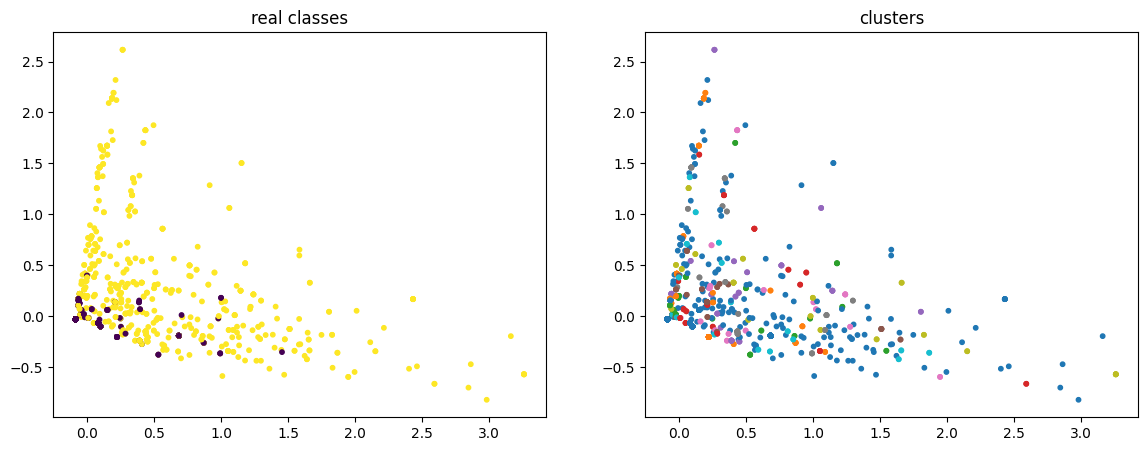

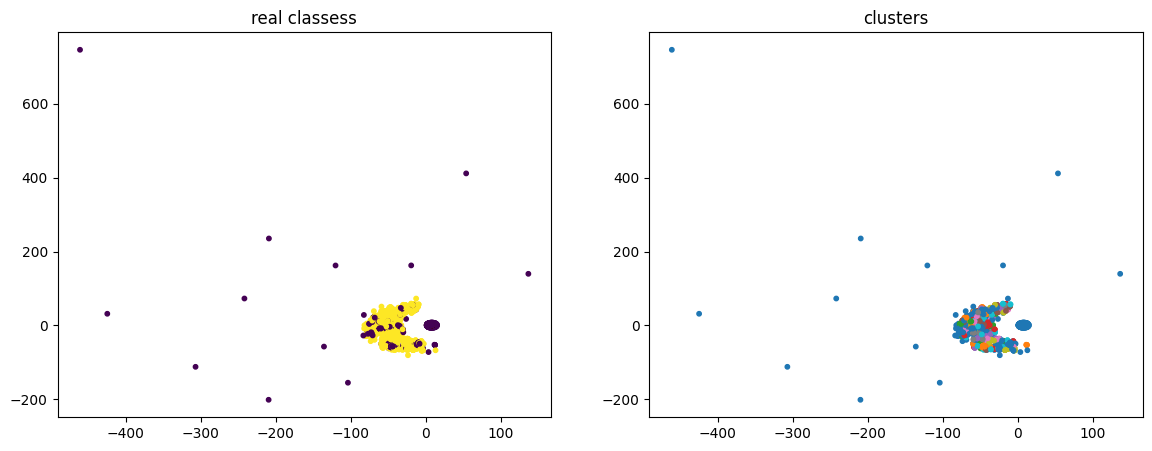

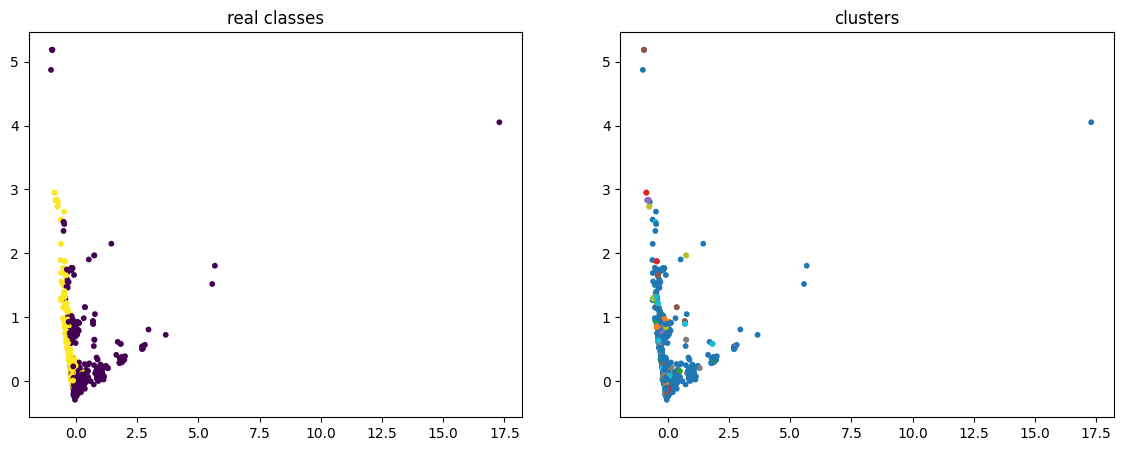

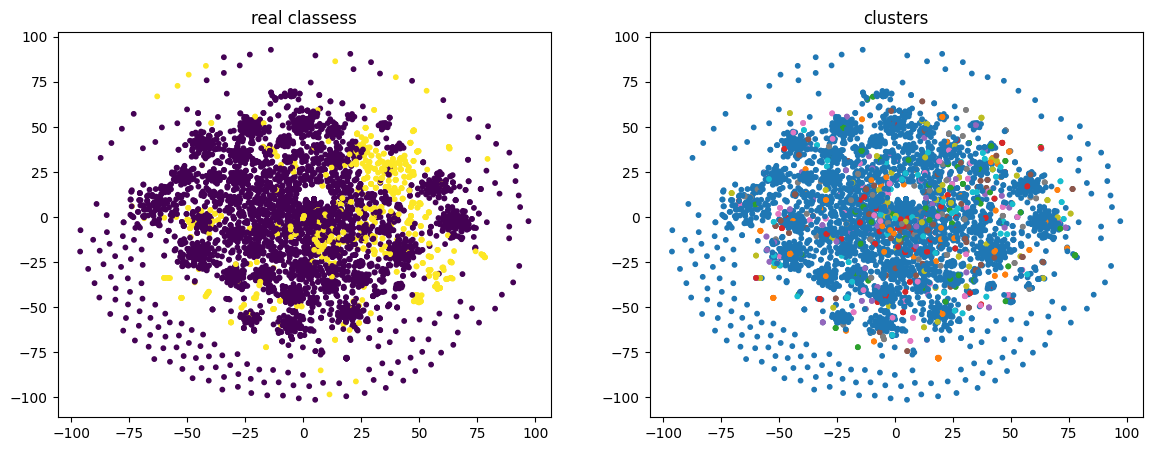

In [10]:
# (10) Визуализация
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# (10.1) PCA
def visualize_PCA(X, y, alg):
    X_pca = PCA(2).fit_transform(X.toarray())
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    ax1.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', s=10)
    ax2.scatter(X_pca[:,0], X_pca[:,1], c=alg(X), cmap='tab10', s=10)
    ax1.set_title('real classes'), ax2.set_title('clusters')
    plt.show()

# (10.1) tSNE
def visualize_tSNE(X, y, alg):
    X_tsne = TSNE(2, random_state=30).fit_transform(X.toarray())
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
    ax1.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='viridis', s=10)
    ax2.scatter(X_tsne[:,0], X_tsne[:,1], c=alg(X), cmap='tab10', s=10)
    ax1.set_title('real classess'), ax2.set_title('clusters')
    plt.show()

visualize_PCA(X_chi2, y, dbscan)
visualize_tSNE(X_chi2, y, dbscan)
visualize_PCA(X_vectorized, y, dbscan)
visualize_tSNE(X_vectorized, y, dbscan)